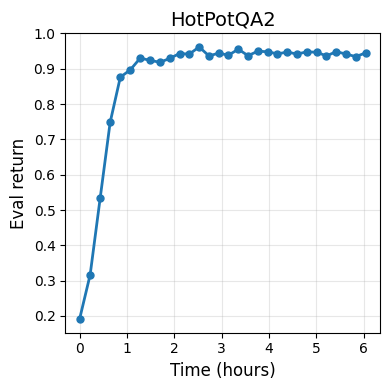

Data with converted time (hours from start):
      hours     Value
0  0.000000  0.191166
1  0.073893  0.173333
2  0.147903  0.259944
3  0.223308  0.316777
4  0.294715  0.481999

Total duration: 6.11 hours


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Read the data
data = """Wall time,Step,Value
1763989518.554466,17,0.1911663711071014
1763989784.570188,3417,0.1733330190181732
1763990051.0060384,6817,0.2599439918994903
1763990322.46342,10217,0.3167772591114044
1763990579.5267043,13617,0.4819991588592529
1763990832.723838,17017,0.605387806892395
1763991085.8543608,20417,0.5342211723327637
1763991329.8540246,23817,0.6482765674591064
1763991585.7754655,27217,0.7439429759979248
1763991842.1437707,30617,0.748054027557373
1763992098.2614348,34017,0.8174982666969299
1763992358.3641477,37417,0.8887757658958435
1763992616.2023776,40817,0.8761091828346252
1763992866.7809007,44217,0.8870535492897034
1763993116.0917156,47617,0.9064979553222656
1763993376.517881,51017,0.8969424366950989
1763993625.4591184,54417,0.882331371307373
1763993874.3692403,57817,0.9192201495170592
1763994132.0500252,61217,0.930220067501068
1763994387.028144,64617,0.9153867959976196
1763994634.2779398,68017,0.936442255973816
1763994890.8819444,71417,0.9235534071922302
1763995137.1212676,74817,0.9431089162826538
1763995394.0149634,78217,0.9279422760009766
1763995640.8729742,81617,0.9183312058448792
1763995886.690766,85017,0.9233311414718628
1763996131.828935,88417,0.9460533261299132
1763996384.986236,91817,0.9294978380203248
1763996631.551695,95217,0.9274422526359558
1763996876.6096418,98617,0.937831163406372
1763997121.6226726,102017,0.9430533647537231
1763997368.4927027,105417,0.9416088461875916
1763997615.058375,108817,0.9334422945976256
1763997862.912574,112217,0.9414422512054444
1763998108.5311325,115617,0.9219979047775269
1763998355.487809,119017,0.9526644349098206
1763998611.0388942,122417,0.9617199301719666
1763998866.210686,125817,0.9001089930534363
1763999112.2735903,129217,0.93894225358963
1763999358.691829,132617,0.936275601387024
1763999605.884969,136017,0.9401644468307496
1763999853.1024332,139417,0.9494422078132628
1764000097.905506,142817,0.944220006465912
1764000342.918735,146217,0.9492200016975404
1764000592.847693,149617,0.9397200345993042
1764000841.35275,153017,0.9382755756378174
1764001090.2822907,156417,0.9467755556106568
1764001337.8112855,159817,0.9322199821472168
1764001586.1037743,163217,0.9553310871124268
1764001836.7747743,166617,0.934386670589447
1764002083.4059756,170017,0.9588310718536376
1764002329.3246882,173417,0.9369978308677672
1764002577.245342,176817,0.9512199759483336
1764002826.3172371,180217,0.9588866233825684
1764003074.527977,183617,0.9497199654579164
1764003320.9873986,187017,0.9389978051185608
1764003569.7539442,190417,0.941997766494751
1764003820.042255,193817,0.9480533003807068
1764004070.0244703,197217,0.9431644678115844
1764004317.8349812,200617,0.950386643409729
1764004566.9609635,204017,0.9421088695526124
1764004813.2544756,207417,0.9339978694915771
1764005061.548694,210817,0.9444422125816344
1764005309.8737197,214217,0.947219967842102
1764005556.9497972,217617,0.937442183494568
1764005808.226202,221017,0.9414977431297302
1764006057.1792636,224417,0.9415533542633056
1764006306.2074287,227817,0.946108877658844
1764006552.9774773,231217,0.9506644606590272
1764006801.283739,234617,0.9478867053985596
1764007050.9645572,238017,0.9454978108406068
1764007300.0051205,241417,0.952775537967682
1764007547.9556403,244817,0.946720004081726
1764007797.6762264,248217,0.9336644411087036
1764008046.0014446,251617,0.9490532875061036
1764008292.764599,255017,0.9363311529159546
1764008541.9383855,258417,0.9440532922744752
1764008791.5188444,261817,0.9326644539833068
1764009037.876917,265217,0.9483866691589355
1764009286.4320498,268617,0.9312755465507508
1764009535.660176,272017,0.9574422240257264
1764009784.9719975,275417,0.941497802734375
1764010031.5291808,278817,0.9339978098869324
1764010280.4911573,282217,0.9502755403518676
1764010529.4752965,285617,0.9343311786651612
1764010779.7200167,289017,0.9479421973228456
1764011027.2869294,292417,0.9559977054595948
1764011275.2252705,295817,0.944997787475586
1764011521.83216,299217,0.9521088600158693
"""

# Read data into pandas DataFrame
df = pd.read_csv(pd.io.common.StringIO(data))

# Convert Wall time (Unix timestamp) to datetime
df['datetime'] = pd.to_datetime(df['Wall time'], unit='s')

# Calculate hours from the start time
start_time = df['datetime'].iloc[0]
df['hours'] = (df['datetime'] - start_time).dt.total_seconds() / 3600.0

# Create the plot
fig = plt.figure(figsize=(4, 4))
plt.plot(df['hours'][::3], df['Value'][::3], marker='o', linewidth=2, markersize=5)

# Customize the plot
plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('Eval return', fontsize=12)
plt.title('HotPotQA2', fontsize=14)
plt.grid(True, alpha=0.3)

# Add some extra visual elements
# plt.fill_between(df['hours'], df['Value'], alpha=0.2)
plt.tight_layout()

# Show the plot
plt.show()

fig.savefig("train_time_hpqa.pdf", dpi=300, bbox_inches='tight')

# Optionally print the data with converted times
print("Data with converted time (hours from start):")
print(df[['hours', 'Value']].head())
print(f"\nTotal duration: {df['hours'].iloc[-1]:.2f} hours")

In [5]:
!pip install matplotlib

  Using cached matplotlib-3.10.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 21.3 MB/s  0:00:00 eta 0:00:01
Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.5 MB)
Using cached pyparsing-3.2.5-py3-none-any.whl (113 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matpl

In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt

# путь
input_path = "/home/jovyan/nazar/multi-step-retrieval-rl/runs/Dec03_12-03-43_QRAG_qa2_two-supporting-facts/episode_logs_q.jsonl"

episodes = []

with open(input_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        episodes.append(json.loads(line))

print("Загружено эпизодов:", len(episodes))
print("Пример эпизода:")
print(episodes[0])

Загружено эпизодов: 500
Пример эпизода:
{'id': 0, 'question': 'Where is the milk? ', 'answer': 'hallway', 'sf_idx': [15, 158], 'pred_idx': [15, 158, 16, 1, 14, 17], 'sf_texts': ['Mary got the milk there.', 'Mary travelled to the hallway.'], 'pred_texts': ['Mary got the milk there.', 'Mary travelled to the hallway.', 'Genie!', 'she answered.', '"Goodness Heavens!', 'What has happened!'], 'q_values': [0.91718590259552, 0.9901180267333984, 0.031774695962667465, 0.015292877331376076, 0.01232861541211605, 0.0058726780116558075], 'return': 0, 'text_len': 10, 'f1': 0, 'em': 0}


In [11]:
def get_earliest_step_with_all_gt(actions, gt_ids):
    gt = set(gt_ids)
    seen = set()
    for i, a in enumerate(actions):
        seen.add(a)
        if gt.issubset(seen):
            return i + 1
    return None

def get_stop_step(q_values, q_border):
    step = 0
    for q in q_values:
        if q < q_border:
            break
        step += 1
    return step

def classify_episode_time_based(ep, q_border):
    actions = ep["pred_idx"]
    gt_ids = ep["sf_idx"]
    q_values = ep["q_values"]

    earliest_step = get_earliest_step_with_all_gt(actions, gt_ids)
    stop_step = get_stop_step(q_values, q_border)

    if earliest_step is None:
        return "not_found"  # агент сам по себе не способен собрать все gt

    if stop_step < earliest_step:
        return "early"
    elif stop_step == earliest_step:
        return "perfect"
    else:
        return "late"

In [12]:
def calc_fact_f1_em(predicted_support_idxs, gt_support_idxs):
    # Taken from hotpot_eval
    pred_sf = set(map(int, predicted_support_idxs))
    gt_sf = set(map(int, gt_support_idxs))
    tp, fp, fn = 0, 0, 0
    for e in pred_sf:
        if e in gt_sf:
            tp += 1
        else:
            fp += 1
    for e in gt_sf:
        if e not in pred_sf:
            fn += 1
    prec = 1.0 * tp / (tp + fp) if tp + fp > 0 else 0.0
    recall = 1.0 * tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * prec * recall / (prec + recall) if prec + recall > 0 else 0.0
    em = 1.0 if gt_sf.issubset(pred_sf) else 0.0

    # In case everything is empty, set both f1, em to be 1.0.
    # Without this change, em gets 1 and f1 gets 0
    if not pred_sf and not gt_sf:
        f1, em = 1.0, 1.0
    return f1, em

In [13]:
# Симулируем выбор чанков при заданном q_border
def simulate_actions(episode, q_border):
    q_values = episode["q_values"]
    actions = episode["pred_idx"]
    reward = 0

    selected = []
    for q, a in zip(q_values, actions):
        # если q < порога, останавливаемся и не берём этот чанк
        if q < q_border:
            break
        selected.append(a)

    f1, em = calc_fact_f1_em(selected, episode["sf_idx"])

    return selected, f1, em, reward

In [14]:
# сетка порогов: от -0.1 до 1.1 с шагом 0.1
q_borders = [round(-0.1 + 0.1 * i, 2) for i in range(13)]

early_rates = []
late_rates = []
fact_em_arr = []
llm_em_arr = []
fact_f1_arr = []
perfect_rates = []
avg_lengths = []  # среднее число выбранных чанков

for q_border in q_borders:
    early = late = perfect = not_found = 0
    lengths = []
    all_em = []
    all_f1 = []
    all_r = []

    for ep in episodes:
        label = classify_episode_time_based(ep, q_border)
        selected, f1, em, reward = simulate_actions(ep, q_border)
        all_em.append(em)
        all_f1.append(f1)
        all_r.append(reward)
        lengths.append(len(selected))
        if label == "early":
            early += 1
        elif label == "late":
            late += 1
        elif label == "perfect":
            perfect += 1
        elif label == "not_found":
            not_found += 1

    n = len(episodes)
    correct_len = n - not_found
    early_rates.append(early / correct_len)
    late_rates.append(late / correct_len)
    perfect_rates.append(perfect / correct_len)
    avg_lengths.append(np.mean(lengths))
    fact_em = sum(all_em) / len(all_em)
    fact_em_arr.append(fact_em)
    llm_em = sum(all_r) / len(all_r)
    llm_em_arr.append(sum(all_r) / len(all_r))
    fact_f1 = sum(all_f1) / len(all_f1)
    fact_f1_arr.append(fact_f1)

    print(
        f"q_border={q_border:.2f} | "
        f"early={early/correct_len:.3f}, late={late/correct_len:.3f}, perfect={perfect/correct_len:.3f}, "
        f"avg_len={np.mean(lengths):.2f}, "
        f'Coverage_score: {round(fact_em, 3)}, F1: {round(fact_f1, 3)}'
    )

q_border=-0.10 | early=0.000, late=0.994, perfect=0.006, avg_len=6.00, Coverage_score: 0.996, F1: 0.499
q_border=0.00 | early=0.000, late=0.994, perfect=0.006, avg_len=6.00, Coverage_score: 0.996, F1: 0.499
q_border=0.10 | early=0.000, late=0.498, perfect=0.502, avg_len=2.86, Coverage_score: 0.996, F1: 0.845
q_border=0.20 | early=0.000, late=0.036, perfect=0.964, avg_len=2.29, Coverage_score: 0.996, F1: 0.949
q_border=0.30 | early=0.006, late=0.010, perfect=0.984, avg_len=2.25, Coverage_score: 0.99, F1: 0.952
q_border=0.40 | early=0.008, late=0.002, perfect=0.990, avg_len=2.24, Coverage_score: 0.988, F1: 0.953
q_border=0.50 | early=0.008, late=0.000, perfect=0.992, avg_len=2.23, Coverage_score: 0.988, F1: 0.954
q_border=0.60 | early=0.016, late=0.000, perfect=0.984, avg_len=2.21, Coverage_score: 0.98, F1: 0.948
q_border=0.70 | early=0.042, late=0.000, perfect=0.958, avg_len=2.16, Coverage_score: 0.954, F1: 0.934
q_border=0.80 | early=0.112, late=0.000, perfect=0.888, avg_len=2.06, Cove

-0.1, F1: 0.884, EM: 0.884
0.0,  F1: 0.884, EM: 0.884
0.1,  F1: 0.944, EM: 0.944
0.2,  F1: 0.976, EM: 0.976
0.3,  F1: 0.970, EM: 0.970
0.4,  F1: 0.970, EM: 0.970
0.5,  F1: 0.972, EM: 0.972
0.6,  F1: 0.968, EM: 0.968
0.7,  F1: 0.948, EM: 0.948
0.8,  F1: 0.884, EM: 0.884
0.9,  F1: 0.830, EM: 0.830
1.0,  F1: 0.230, EM: 0.230
1.1,  F1: 0.0, EM: 0.0

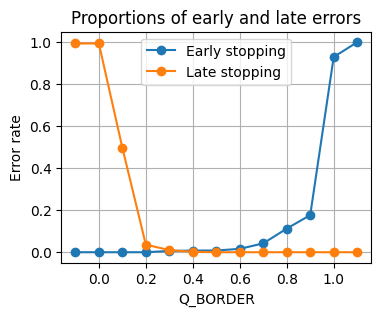

In [15]:
# График: error rate vs q_border
plt.figure(figsize=(4, 3))
plt.plot(q_borders, early_rates, marker="o", label="Early stopping")
plt.plot(q_borders, late_rates, marker="o", label="Late stopping")
plt.xlabel("Q_BORDER")
plt.ylabel("Error rate")
plt.grid(True)
plt.legend()
plt.title("Proportions of early and late errors")
plt.show()

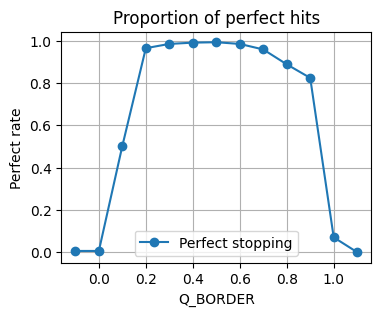

In [16]:
# График: perfect_rates vs q_border
plt.figure(figsize=(4, 3))
plt.plot(q_borders, perfect_rates, marker="o", label="Perfect stopping")
plt.xlabel("Q_BORDER")
plt.ylabel("Perfect rate")
plt.grid(True)
plt.legend()
plt.title("Proportion of perfect hits")
plt.show()

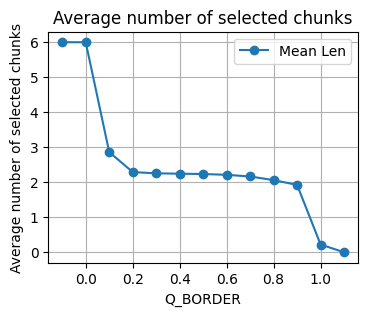

In [17]:
# График: avg_lengths vs q_border
plt.figure(figsize=(4, 3))
plt.plot(q_borders, avg_lengths, marker="o", label="Mean Len")
plt.xlabel("Q_BORDER")
plt.ylabel("Average number of selected chunks")
plt.grid(True)
plt.legend()
plt.title("Average number of selected chunks")
plt.show()

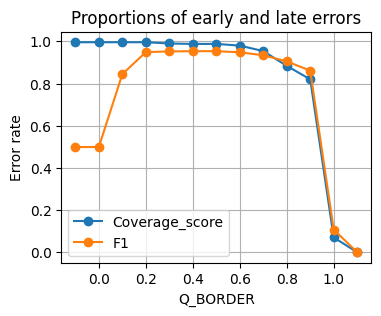

In [18]:
# График: error rate vs q_border
plt.figure(figsize=(4, 3))
plt.plot(q_borders, fact_em_arr, marker="o", label="Coverage_score")
plt.plot(q_borders, fact_f1_arr, marker="o", label="F1")
plt.xlabel("Q_BORDER")
plt.ylabel("Error rate")
plt.grid(True)
plt.legend()
plt.title("Proportions of early and late errors")
plt.show()

In [23]:
def calc_fact_f1_em(predicted_support_idxs, gt_support_idxs, total_elements):
    # Taken from hotpot_eval
    pred_sf = set(map(int, predicted_support_idxs))
    gt_sf = set(map(int, gt_support_idxs))
    tp, fp, fn = 0, 0, 0
    for e in pred_sf:
        if e in gt_sf:
            tp += 1
        else:
            fp += 1
    for e in gt_sf:
        if e not in pred_sf:
            fn += 1
    prec = 1.0 * tp / (tp + fp) if tp + fp > 0 else 0.0
    recall = 1.0 * tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * prec * recall / (prec + recall) if prec + recall > 0 else 0.0
    em = 1.0 if gt_sf.issubset(pred_sf) else 0.0

    tn = total_elements - len(gt_sf) - fp
    tpr = 1.0 * tp / (tp + fn) if tp + fn > 0 else 0.0
    fpr = 1.0 * fp / (fp + tn) if (fp + tn) > 0 else 0.0

    # In case everything is empty, set both f1, em to be 1.0.
    # Without this change, em gets 1 and f1 gets 0
    if not pred_sf and not gt_sf:
        f1, em = 1.0, 1.0
    return f1, em, tpr, fpr

In [32]:
def simulate_actions(episode, q_border):
    q_values = episode["q_values"]
    actions = episode["pred_idx"]

    selected = []
    for q, a in zip(q_values, actions):
        # если q < порога, останавливаемся и не берём этот чанк
        if q < q_border:
            break
        selected.append(a)

    f1, em, tpr, fpr = calc_fact_f1_em(selected, episode["sf_idx"], total_elements=6)

    return selected, f1, em, tpr, fpr

In [33]:
# сетка порогов: от -0.1 до 1.1 с шагом 0.1
q_borders = [round(-0.1 + 0.1 * i, 2) for i in range(13)]

early_rates = []
late_rates = []
fact_em_arr = []
fact_f1_arr = []
tpr_arr = []
fpr_arr = []
perfect_rates = []
avg_lengths = []  # среднее число выбранных чанков

for q_border in q_borders:
    early = late = perfect = not_found = 0
    lengths = []
    all_em = []
    all_f1 = []
    all_tpr = []
    all_fpr = []

    for ep in episodes:
        label = classify_episode_time_based(ep, q_border)
        selected, f1, em, tpr, fpr = simulate_actions(ep, q_border)
        all_em.append(em)
        all_f1.append(f1)
        all_tpr.append(tpr)
        all_fpr.append(fpr)
        lengths.append(len(selected))
        if label == "early":
            early += 1
        elif label == "late":
            late += 1
        elif label == "perfect":
            perfect += 1
        elif label == "not_found":
            not_found += 1

    n = len(episodes)
    correct_len = n - not_found
    early_rates.append(early / correct_len)
    late_rates.append(late / correct_len)
    perfect_rates.append(perfect / correct_len)
    avg_lengths.append(np.mean(lengths))
    fact_em = sum(all_em) / len(all_em)
    fact_em_arr.append(fact_em)
    fact_f1 = sum(all_f1) / len(all_f1)
    fact_f1_arr.append(fact_f1)
    tpr_avg = sum(all_tpr) / len(all_tpr)
    fpr_avg = sum(all_fpr) / len(all_fpr)
    tpr_arr.append(tpr_avg)
    fpr_arr.append(fpr_avg)

    print(
        f"q_border={q_border:.2f} | "
        f"early={early/correct_len:.3f}, late={late/correct_len:.3f}, perfect={perfect/correct_len:.3f}, "
        f"avg_len={np.mean(lengths):.2f}, "
        f"tpr_avg={tpr_avg:.3f}, fpr_avg={fpr_avg:.3f}, "
        f'Coverage_score: {round(fact_em, 3)}, F1: {round(fact_f1, 3)}'
    )

q_border=-0.10 | early=0.000, late=0.994, perfect=0.006, avg_len=6.00, tpr_avg=0.998, fpr_avg=1.001, Coverage_score: 0.996, F1: 0.499
q_border=0.00 | early=0.000, late=0.994, perfect=0.006, avg_len=6.00, tpr_avg=0.998, fpr_avg=1.001, Coverage_score: 0.996, F1: 0.499
q_border=0.10 | early=0.000, late=0.498, perfect=0.502, avg_len=2.86, tpr_avg=0.998, fpr_avg=0.216, Coverage_score: 0.996, F1: 0.845
q_border=0.20 | early=0.000, late=0.036, perfect=0.964, avg_len=2.29, tpr_avg=0.998, fpr_avg=0.073, Coverage_score: 0.996, F1: 0.949
q_border=0.30 | early=0.006, late=0.010, perfect=0.984, avg_len=2.25, tpr_avg=0.994, fpr_avg=0.067, Coverage_score: 0.99, F1: 0.952
q_border=0.40 | early=0.008, late=0.002, perfect=0.990, avg_len=2.24, tpr_avg=0.993, fpr_avg=0.065, Coverage_score: 0.988, F1: 0.953
q_border=0.50 | early=0.008, late=0.000, perfect=0.992, avg_len=2.23, tpr_avg=0.992, fpr_avg=0.062, Coverage_score: 0.988, F1: 0.954
q_border=0.60 | early=0.016, late=0.000, perfect=0.984, avg_len=2.21,

[0.    0.1   0.861 0.915 0.961 0.983 0.992 0.993 0.994 0.998 0.998 0.998]
[0.     0.005  0.0505 0.0575 0.0605 0.0615 0.0625 0.0645 0.0665 0.0735
 0.2165 1.001 ]


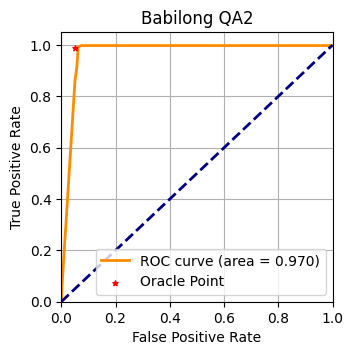

ROC AUC Score: 0.9697


In [53]:
from sklearn.metrics import roc_curve, auc

tpr = np.array(tpr_arr)
fpr = np.array(fpr_arr)

# 1. сортируем по FPR
order = np.argsort(fpr)
fpr_sorted = fpr[order]
tpr_sorted = tpr[order]

# 2. убираем дубли по FPR (оставляем первую точку с таким FPR)
fpr_unique, idx = np.unique(fpr_sorted, return_index=True)
tpr_unique = tpr_sorted[idx]

print(tpr_unique)
print(fpr_unique)

# 3. считаем AUC
roc_auc = auc(fpr_unique, tpr_unique)

oracle_tpr = [0 , 0.995, 1]
oracle_fpr = [0, 0.051, 1]


# Calculate the Area Under the Curve (AUC)
#roc_auc = auc(fpr[::-1], tpr[::-1])
roc_auc_oracle = auc(oracle_fpr, oracle_tpr)
# Alternatively, you can directly use roc_auc_score:
# roc_auc_score_direct = roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve
fig = plt.figure(figsize=(3.5, 3.5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
#plt.plot(oracle_fpr, oracle_tpr, color='navy', lw=2, label=f'ROC_oracle curve (area = {roc_auc_oracle:.3f})')
plt.scatter([0.05], [0.99], color='red', marker='*', s=15, zorder=10, label='Oracle Point')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Babilong QA2')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



print(f"ROC AUC Score: {roc_auc:.4f}")

fig.savefig("roc_auc_qa2.pdf", dpi=600, bbox_inches='tight')

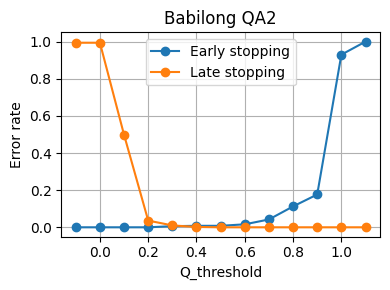

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
plt.plot(q_borders, early_rates, marker="o", label="Early stopping")
plt.plot(q_borders, late_rates, marker="o", label="Late stopping")
plt.xlabel("Q_threshold")
plt.ylabel("Error rate")
plt.grid(True)
plt.legend()
plt.title("Babilong QA2")

plt.tight_layout()
plt.savefig("early-late-errors-qa2.pdf", dpi=600, bbox_inches="tight")

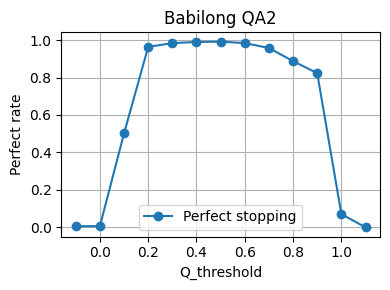

In [59]:
plt.figure(figsize=(4, 3))
plt.plot(q_borders, perfect_rates, marker="o", label="Perfect stopping")
plt.xlabel("Q_threshold")
plt.ylabel("Perfect rate")
plt.grid(True)
plt.legend()
plt.title("Babilong QA2")

plt.tight_layout()
plt.savefig("perfect-stops-qa2.pdf", dpi=600, bbox_inches="tight")

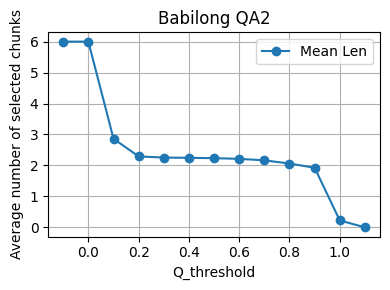

In [58]:
plt.figure(figsize=(4, 3))
plt.plot(q_borders, avg_lengths, marker="o", label="Mean Len")
plt.xlabel("Q_threshold")
plt.ylabel("Average number of selected chunks")
plt.grid(True)
plt.legend()
plt.title("Babilong QA2")

plt.tight_layout()
plt.savefig("avg-len-qa2.pdf", dpi=600, bbox_inches="tight")

In [28]:
!pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.5 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
